# MiniPAR Calibration using Multi-Channel Spec
## Calibrate MiniPAR sensor using AS7341 multi-channel spectral data
This notebook reads multi-channel 'spec' output, performs multi-input linear regression against a reference PAR sensor, inspects coefficients, visualizes fit quality, analyzes channel independence, and validates the calibration.

## Setup: Imports and Helper Functions

In [ ]:
import sys
import time
import serial
import glob
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')
from helpers import findDevice, get_par_MP, plot_data_and_fit, get_MP_name, r_squared

# Configuration
BAUD_RATE = 115200


## Device Discovery
Automatically detect MiniPAR, reference sensor, and DC source ports, or specify manually.

In [57]:
# clear ports

PORT_MINIPAR = None
PORT_REF = None


In [59]:
# Try auto-detection
print("Scanning for MiniPAR...")

print("\nScanning for reference sensor (TIA)...")
if not PORT_REF:
    PORT_REF = findDevice(question="\x01", answer="raw", flush=True, timeout=2)
    if(PORT_REF):
        with serial.Serial(PORT_REF) as ser:
            ser.write("\x02\x04".encode())
            ser.flush()
if not PORT_REF:
    print("Reference sensor not found. Set PORT_REF manually in next cell.")

if not PORT_MINIPAR:
    PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)
if not PORT_MINIPAR:
    print("MiniPAR not found. Set PORT_MINIPAR manually in next cell.")



print(f"\nPORT_MINIPAR: {PORT_MINIPAR}")
print(f"PORT_REF: {PORT_REF}")


Scanning for MiniPAR...

Scanning for reference sensor (TIA)...
Received message: MiniPAR,1.1, port: /dev/ttyACM1
Found device at: /dev/ttyACM1, answer: MiniPAR,1.1


PORT_MINIPAR: /dev/ttyACM1
PORT_REF: /dev/ttyACM0


In [60]:
# Uncomment and set if auto-detection fails
# PORT_MINIPAR = "/dev/ttyUSB0"
# PORT_DC = "/
# Verify ports are set
assert PORT_MINIPAR, "PORT_MINIPAR not set"
assert PORT_REF, "PORT_REF not set"
print(f"Using MiniPAR at {PORT_MINIPAR}, Reference at {PORT_REF}")

Using MiniPAR at /dev/ttyACM1, Reference at /dev/ttyACM0


## Serial Communication Functions

In [ ]:
def get_spec(port):
    """Request 'spec' from MiniPAR and return list of channel floats."""
    with serial.Serial(port, baudrate=BAUD_RATE, timeout=1) as ser:
        ser.reset_input_buffer()
        ser.write("spec_raw\n".encode())
        time.sleep(0.2)
        line = ser.readline().decode(errors='ignore').strip()
    if not line:
        raise RuntimeError(f"No response from {port}")
    
    parts = [p.strip() for p in line.split(',') if p.strip()]
    # Skip device name if present
    try:
        if parts[0] and not parts[0][0].isdigit():
            parts = parts[1:]
    except Exception:
        pass
    
    return np.array([float(x) for x in parts], dtype=float)


def getPAR_TIA(port):
    with serial.Serial(port) as ser:
        ser.flush()
        ser.write("getPAR()\r".encode())
        response = ser.readline()# skip echo
        #print(response)
        response = ser.readline()
        #print(response)
    return float(response)




print("Serial functions loaded.")

print(getPAR_TIA(PORT_REF))
print(get_par_MP(PORT_MINIPAR, raw=False))
print(get_spec(PORT_MINIPAR))


Serial functions loaded.
54.437936
7.77
[0.2182 0.3273 0.215  0.0846 0.0475 0.0738 0.2707 0.0776 0.     0.    ]


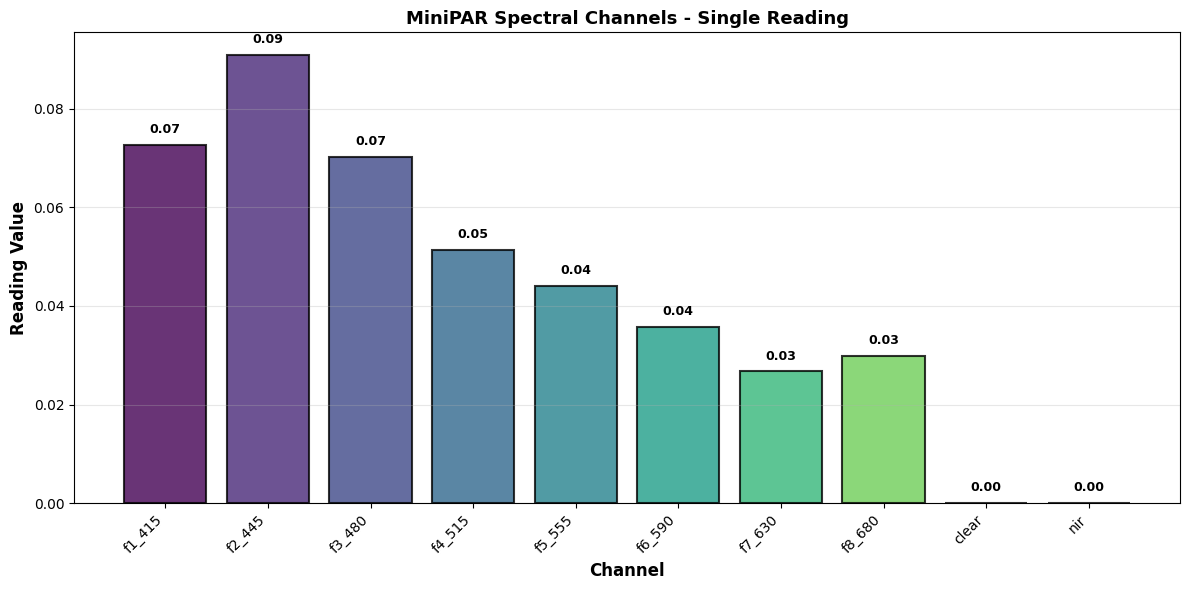


Channel readings:
  f1_415: 0.0727
  f2_445: 0.0909
  f3_480: 0.0701
  f4_515: 0.0513
  f5_555: 0.0441
  f6_590: 0.0357
  f7_630: 0.0267
  f8_680: 0.0299
  clear: 0.0000
  nir: 0.0000

Number of channels: 10


In [19]:
# test reading
single_reading = get_spec(PORT_MINIPAR)

all_channel_names = ["f1_415", "f2_445", "f3_480", "f4_515",
                     "f5_555", "f6_590", "f7_630", "f8_680",
                     "clear",  "nir"]

# Display channel readings on bar graph
fig, ax = plt.subplots(figsize=(12, 6))
channels = np.arange(1, len(single_reading) + 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(single_reading)))
bars = ax.bar(channels, single_reading, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, single_reading)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(single_reading)*0.02, 
            f'{value:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
ax.set_ylabel('Reading Value', fontsize=12, fontweight='bold')
ax.set_title('MiniPAR Spectral Channels - Single Reading', fontsize=13, fontweight='bold')
ax.set_xticks(channels)
ax.set_xticklabels(all_channel_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nChannel readings:")
for name, value in zip(all_channel_names, single_reading):
    print(f"  {name}: {value:.4f}")
print(f"\nNumber of channels: {len(single_reading)}")


Manual collection ready.
Saved readings file: manual_spec_readings.csv


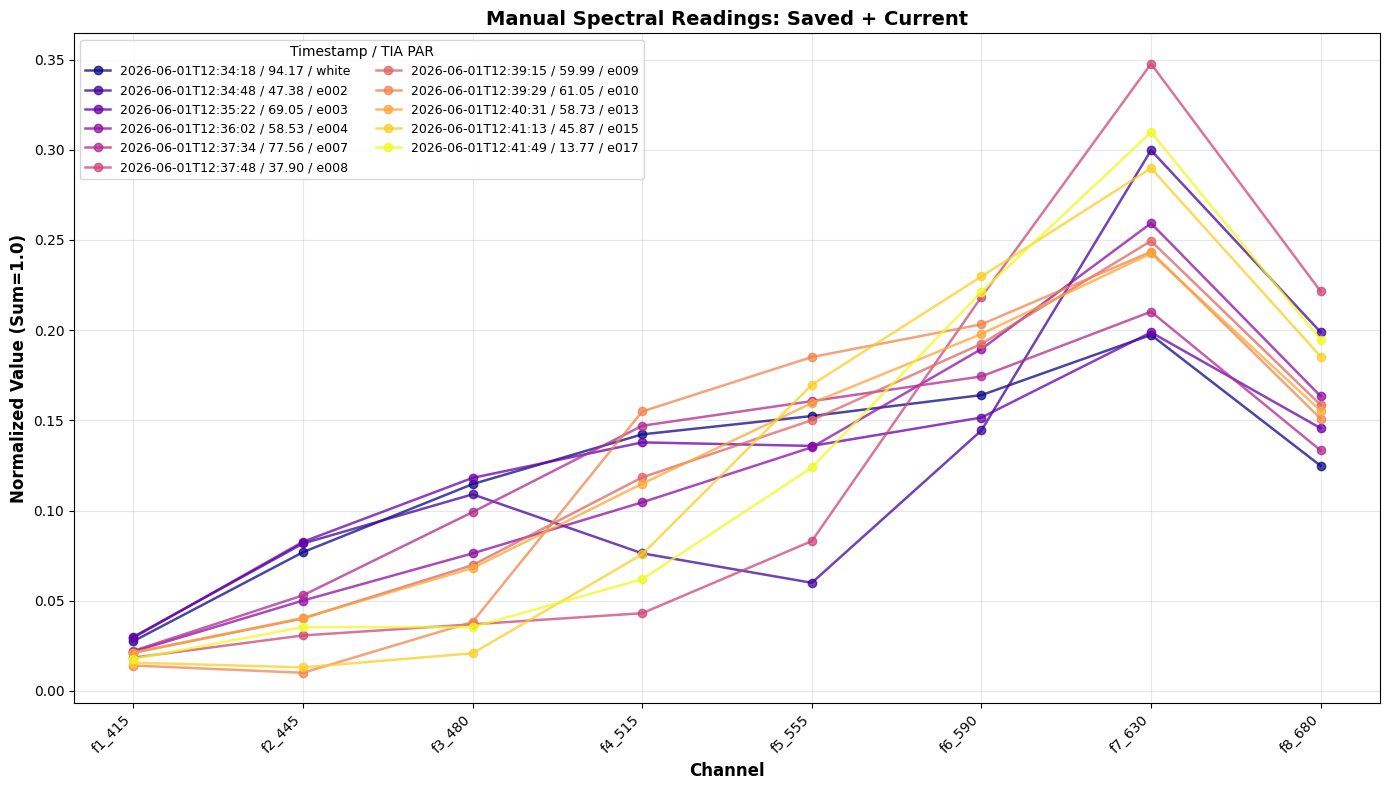

Read error: [Errno 2] could not open port /dev/ttyACM0: [Errno 2] No such file or directory: '/dev/ttyACM0'
Read error: [Errno 2] could not open port /dev/ttyACM0: [Errno 2] No such file or directory: '/dev/ttyACM0'
Read error: [Errno 2] could not open port /dev/ttyACM0: [Errno 2] No such file or directory: '/dev/ttyACM0'


KeyboardInterrupt: Interrupted by user

In [55]:
# collect data manually by changing light and recording PAR from TIA and spec from MiniPAR
csv_path = 'manual_spec_readings.csv'
manual_channel_names = ['f1_415', 'f2_445', 'f3_480', 'f4_515',
                         'f5_555', 'f6_590', 'f7_630', 'f8_680',
                         'clear',  'nir']

from IPython.display import clear_output

def load_manual_readings(path):
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
        except Exception as e:
            raise RuntimeError(f'Could not read {path}: {e}')
    else:
        df = pd.DataFrame(columns=['timestamp', 'tia_par', 'filter_name'] + manual_channel_names)
    if 'filter_name' not in df.columns:
        df['filter_name'] = ''
    return df

def plot_manual_spectra(df, current_spec=None, current_label=None, skip_last_channels=2):
    channel_names = manual_channel_names[:-skip_last_channels] if skip_last_channels > 0 else manual_channel_names
    selected_names = manual_channel_names[:-skip_last_channels] if skip_last_channels > 0 else manual_channel_names
    fig, ax = plt.subplots(figsize=(14, 8))
    plotted = False

    if not df.empty:
        norm_df = df[selected_names].div(df[selected_names].sum(axis=1), axis=0)
        colors = plt.cm.plasma(np.linspace(0, 1, len(norm_df)))
        for plot_idx, (row_idx, row) in enumerate(norm_df.iterrows()):
            filter_name = df.loc[row_idx, 'filter_name'] if 'filter_name' in df.columns else ''
            label = f'{df.loc[row_idx, "timestamp"]} / {df.loc[row_idx, "tia_par"]:.2f}'
            if filter_name:
                label += f' / {filter_name}'
            ax.plot(np.arange(1, len(row) + 1), row.values, marker='o', linewidth=1.8, markersize=6,
                    alpha=0.75, color=colors[plot_idx], label=label)
            plotted = True

    if current_spec is not None:
        spec_arr = np.array(current_spec, dtype=float)
        if skip_last_channels > 0:
            spec_arr = spec_arr[:-skip_last_channels]
        if spec_arr.sum() != 0:
            spec_plot = spec_arr / spec_arr.sum()
        else:
            spec_plot = spec_arr
        ax.plot(np.arange(1, len(spec_plot) + 1), spec_plot, marker='o', linewidth=3, markersize=8,
                color='black', label=current_label or 'Current reading')
        plotted = True

    if not plotted:
        print('No spectral data to display yet.')
        return

    ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Value (Sum=1.0)', fontsize=12, fontweight='bold')
    ax.set_title('Manual Spectral Readings: Saved + Current', fontsize=14, fontweight='bold')
    ax.set_xticks(np.arange(1, len(channel_names) + 1))
    ax.set_xticklabels(channel_names, rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Timestamp / TIA PAR', fontsize=9, title_fontsize=10, loc='best', ncol=2)
    plt.tight_layout()
    plt.show()

def append_manual_reading(path, row):
    row_df = pd.DataFrame([row])
    if not os.path.exists(path):
        row_df.to_csv(path, index=False)
    else:
        row_df.to_csv(path, index=False, header=False, mode='a')

manual_df = load_manual_readings(csv_path)
print('Manual collection ready.')
print(f'Saved readings file: {csv_path}')
plot_manual_spectra(manual_df)

while True:
    user_input = input('Press Enter to capture next reading, or type esc + Enter to exit: ').strip().lower()
    if user_input in {'esc', 'exit', 'quit'}:
        print('Exiting manual collection loop.')
        break

    try:
        tia_value = getPAR_TIA(PORT_REF)
        spec_values = get_spec(PORT_MINIPAR)
    except Exception as e:
        print(f'Read error: {e}')
        continue

    clear_output(wait=True)
    print(f'TIA PAR reading: {tia_value:.6f}')
    plot_manual_spectra(manual_df, current_spec=spec_values, current_label=f'Current @ {tia_value:.2f}')

    filter_name = input('Enter filter name to save this reading (leave blank to reject): ').strip()
    if not filter_name:
        print('No filter name entered; reading rejected.')
        plot_manual_spectra(manual_df, current_spec=spec_values, current_label=f'Current @ {tia_value:.2f}')
        continue

    new_row = {'timestamp': pd.Timestamp.now().isoformat(timespec='seconds'), 'tia_par': float(tia_value), 'filter_name': filter_name}
    new_row.update({name: float(val) for name, val in zip(manual_channel_names, spec_values)})
    append_manual_reading(csv_path, new_row)
    manual_df = pd.concat([manual_df, pd.DataFrame([new_row])], ignore_index=True)
    clear_output(wait=True)
    print(f'Reading saved to {csv_path}')
    plot_manual_spectra(manual_df)


In [79]:
# Preview saved manual spec readings
def preview_manual_readings(path='manual_spec_readings.csv', n=10):
    if not os.path.exists(path):
        print(f'No manual readings file found at {path}')
        return None
    df = pd.read_csv(path)
    if df.empty:
        print(f'{path} is empty')
        return df
    print(f'Preview first {n} rows from {path} (total rows: {len(df)})')
    print(df.head(n).to_string(index=False))
    return df

# Call the helper to preview the CSV contents
preview_manual_readings()


Preview first 10 rows from manual_spec_readings.csv (total rows: 322)
          timestamp   tia_par filter_name  f1_415  f2_445  f3_480  f4_515  f5_555  f6_590  f7_630  f8_680   clear    nir
2026-06-01T13:31:09 99.524550       white  1221.0  3474.0  5192.0  6385.0  6670.0  7211.0  8892.0  5603.0 21428.0 1445.0
2026-06-01T13:31:26 99.327130       white  1220.0  3466.0  5183.0  6374.0  6664.0  7200.0  8875.0  5590.0 21390.0 1443.0
2026-06-01T13:32:15 48.145056        e002   676.0  1912.0  2443.0  1653.0  1327.0  3291.0  6918.0  4610.0 11168.0  858.0
2026-06-01T13:32:50 72.921720        e003   951.0  2742.0  3957.0  4539.0  4438.0  4992.0  6668.0  4835.0 16023.0 1093.0
2026-06-01T13:33:28 61.446480        e004   684.0  1523.0  2283.0  3090.0  3912.0  5576.0  7704.0  4857.0 14138.0 1088.0
2026-06-01T13:34:01 81.534328        e007   860.0  2011.0  3823.0  5563.0  5964.0  6486.0  7979.0  5027.0 17989.0 1278.0
2026-06-01T13:34:39 39.557130        e008   416.0   677.0   753.0   887.0  1722.0  

,timestamp,tia_par,filter_name,f1_415,f2_445,f3_480,f4_515,f5_555,f6_590,f7_630,f8_680,clear,nir
0,2026-06-01T13:31:09,99.524550,white,1221.0,3474.0,5192.0,6385.0,6670.0,7211.0,8892.0,5603.0,21428.0,1445.0
1,2026-06-01T13:31:26,99.327130,white,1220.0,3466.0,5183.0,6374.0,6664.0,7200.0,8875.0,5590.0,21390.0,1443.0
2,2026-06-01T13:32:15,48.145056,e002,676.0,1912.0,2443.0,1653.0,1327.0,3291.0,6918.0,4610.0,11168.0,858.0
3,2026-06-01T13:32:50,72.921720,e003,951.0,2742.0,3957.0,4539.0,4438.0,4992.0,6668.0,4835.0,16023.0,1093.0
4,2026-06-01T13:33:28,61.446480,e004,684.0,1523.0,2283.0,3090.0,3912.0,5576.0,7704.0,4857.0,14138.0,1088.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,2026-06-02T13:36:43,7.574505,E735,592.0,696.0,1143.0,1983.0,955.0,822.0,745.0,625.0,11502.0,23179.0
318,2026-06-02T13:37:23,1.577762,E741,677.0,795.0,762.0,837.0,757.0,1100.0,957.0,1268.0,13155.0,24080.0
319,2026-06-02T13:38:52,63.692170,e604,1296.0,1443.0,1811.0,2752.0,3697.0,5294.0,9246.0,13729.0,29831.0,25804.0
320,2026-06-02T13:40:06,46.096790,E136,1467.0,1918.0,2422.0,2923.0,3194.0,4081.0,7629.0,15559.0,31612.0,29104.0


## Data Collection
Collect spectral data and reference PAR values across multiple current levels.

## Linear Regression: Multiple Input Channels

Loaded 265 manual readings from manual_spec_readings.csv for regression.
LINEAR REGRESSION RESULTS

Matrix rank: 9 / 8
Residual norm: 34.5569

Fit Quality:
  R²: 0.99972393
  RMSE: 0.36111426

Coefficients:
  Channel 1: 0.0071893623
  Channel 2: 0.0030996722
  Channel 3: 0.0024531714
  Channel 4: 0.0025467238
  Channel 5: 0.0021355001
  Channel 6: 0.0019984188
  Channel 7: 0.0022381758
  Channel 8: 0.00047663453
  Intercept:  -0.52597588


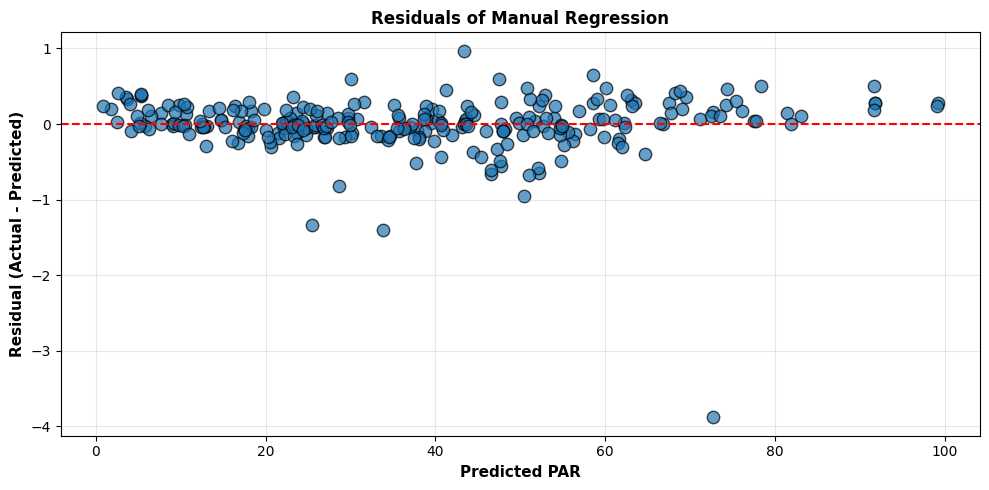

In [109]:
def load_manual_regression(path='manual_spec_readings.csv', channel_names=None):
    df = load_manual_readings(path)
    if df.empty:
        raise ValueError(f"No manual regression data found in {path}")
    if channel_names is None:
        channel_names = manual_channel_names
    missing = [c for c in channel_names if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected spectral columns in {path}: {missing}")
    X = df[channel_names].astype(float).to_numpy()
    y = df['tia_par'].astype(float).to_numpy()
    return X, y, df


X, y, df = load_manual_regression(csv_path, manual_channel_names)
X = X[:, :8]  # Use only the first 8 channels for regression

X_manual = X

y_manual = y
print(f"Loaded {X_manual.shape[0]} manual readings from {csv_path} for regression.")

def compute_coeffs(X, y):
    """Fit multi-input linear regression: y ≈ X @ c + intercept"""
    A = np.hstack([X, np.ones((X.shape[0], 1))])  # [ch1, ch2, ..., 1]
    coeffs, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
    return coeffs, residuals, rank, s


def r_squared(y_true, y_pred):
    """Calculate R² fit quality."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    return 1 - ss_res / ss_tot


# Perform regression
coeffs, residuals, rank, s = compute_coeffs(X, y)
intercept = coeffs[-1]
channels_coeffs = coeffs[:-1]

y_pred = (X @ channels_coeffs) + intercept
r2 = r_squared(y, y_pred)
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"\nMatrix rank: {rank} / {X.shape[1]}")
print(f"Residual norm: {np.linalg.norm(residuals):.6g}")
print(f"\nFit Quality:")
print(f"  R²: {r2:.8g}")
print(f"  RMSE: {rmse:.8g}")
print(f"\nCoefficients:")
for i, c in enumerate(channels_coeffs, start=1):
    print(f"  Channel {i}: {c:.8g}")
print(f"  Intercept:  {intercept:.8g}")
print("=" * 60)

# Residual plot
residuals = y - y_pred
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_pred, residuals, s=80, alpha=0.7, edgecolors='k', linewidth=1)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted PAR', fontsize=11, fontweight='bold')
ax.set_ylabel('Residual (Actual - Predicted)', fontsize=11, fontweight='bold')
ax.set_title('Residuals of Manual Regression', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [110]:
# Display top manual regression outliers by absolute fit error
outlier_df = df.copy()
outlier_df['predicted_par'] = y_pred
outlier_df['residual'] = y - y_pred
outlier_df['abs_error'] = np.abs(outlier_df['residual'])
outlier_df['filter_name'] = outlier_df.get('filter_name', '').fillna('').astype(str)
outlier_df = outlier_df.sort_values('abs_error', ascending=False)
print(f'Loaded {len(outlier_df)} manual readings, showing top outliers by fit error:')
display(outlier_df[['timestamp', 'filter_name', 'tia_par', 'predicted_par', 'residual', 'abs_error']].head(10))


Loaded 265 manual readings, showing top outliers by fit error:


,timestamp,filter_name,tia_par,predicted_par,residual,abs_error
178,2026-06-01T16:09:01,e503,68.775824,72.655698,-3.879874,3.879874
110,2026-06-01T15:06:47,e194,32.474560,33.882161,-1.407601,1.407601
130,2026-06-01T15:22:23,e219,24.182766,25.514040,-1.331274,1.331274
69,2026-06-01T14:29:28,e136,44.319976,43.349245,0.970731,0.970731
200,2026-06-01T16:56:11,e708,49.502347,50.448924,-0.946578,0.946578
212,2026-06-01T17:07:15,e720,27.835102,28.654332,-0.819230,0.819230
238,2026-06-02T12:56:38,e749,50.316716,50.992541,-0.675825,0.675825
104,2026-06-01T15:02:20,e188,45.948724,46.611038,-0.662314,0.662314
181,2026-06-01T16:12:20,e506,59.176104,58.531615,0.644489,0.644489
107,2026-06-01T15:04:18,e191,51.575296,52.217715,-0.642419,0.642419


## Analysis: Channel Independence (SVD)

In [105]:
X, y, df = load_manual_regression(csv_path, manual_channel_names)
X = X[:, :8]  # Use only the first 8 channels for regression
X_manual = X
y_manual = y

# Perform SVD on normalized manual regression spectral data
X_normalized = (X_manual - X_manual.mean(axis=0)) / (X_manual.std(axis=0) + 1e-10)
U, singular_values, Vt = np.linalg.svd(X_normalized, full_matrices=False)

# Compute condition number and variance explained
cond_number = singular_values[0] / singular_values[-1] if singular_values[-1] > 0 else np.inf
variance_explained = (singular_values ** 2) / np.sum(singular_values ** 2)
cumulative_variance = np.cumsum(variance_explained)

print("\n" + "=" * 60)
print("CHANNEL INDEPENDENCE ANALYSIS (SVD)")
print("=" * 60)
print(f"\nCondition number: {cond_number:.4g}")
print(f"  (>100 suggests channel redundancy/collinearity)")
print(f"\nSingular values: {singular_values}")
print(f"\nVariance explained by each component:")
for i, (var, cumvar) in enumerate(zip(variance_explained, cumulative_variance), start=1):
    print(f"  PC{i}: {var*100:6.2f}% (cumulative: {cumvar*100:6.2f}%)")

# Find number of components needed for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents for 95% variance: {n_components_95} / {len(singular_values)}")
if n_components_95 < len(singular_values):
    print(f"  ⚠ Suggests {len(singular_values) - n_components_95} channels are redundant")

print("=" * 60)


CHANNEL INDEPENDENCE ANALYSIS (SVD)

Condition number: 51.44
  (>100 suggests channel redundancy/collinearity)

Singular values: [37.42094343 22.70258437 13.0205259   4.68406502  2.94209486  1.61709261
  0.9955066   0.72742829]

Variance explained by each component:
  PC1:  66.05% (cumulative:  66.05%)
  PC2:  24.31% (cumulative:  90.36%)
  PC3:   8.00% (cumulative:  98.36%)
  PC4:   1.03% (cumulative:  99.40%)
  PC5:   0.41% (cumulative:  99.80%)
  PC6:   0.12% (cumulative:  99.93%)
  PC7:   0.05% (cumulative:  99.98%)
  PC8:   0.02% (cumulative: 100.00%)

Components for 95% variance: 3 / 8
  ⚠ Suggests 5 channels are redundant


## Visualization: Fit Quality and Channel Analysis

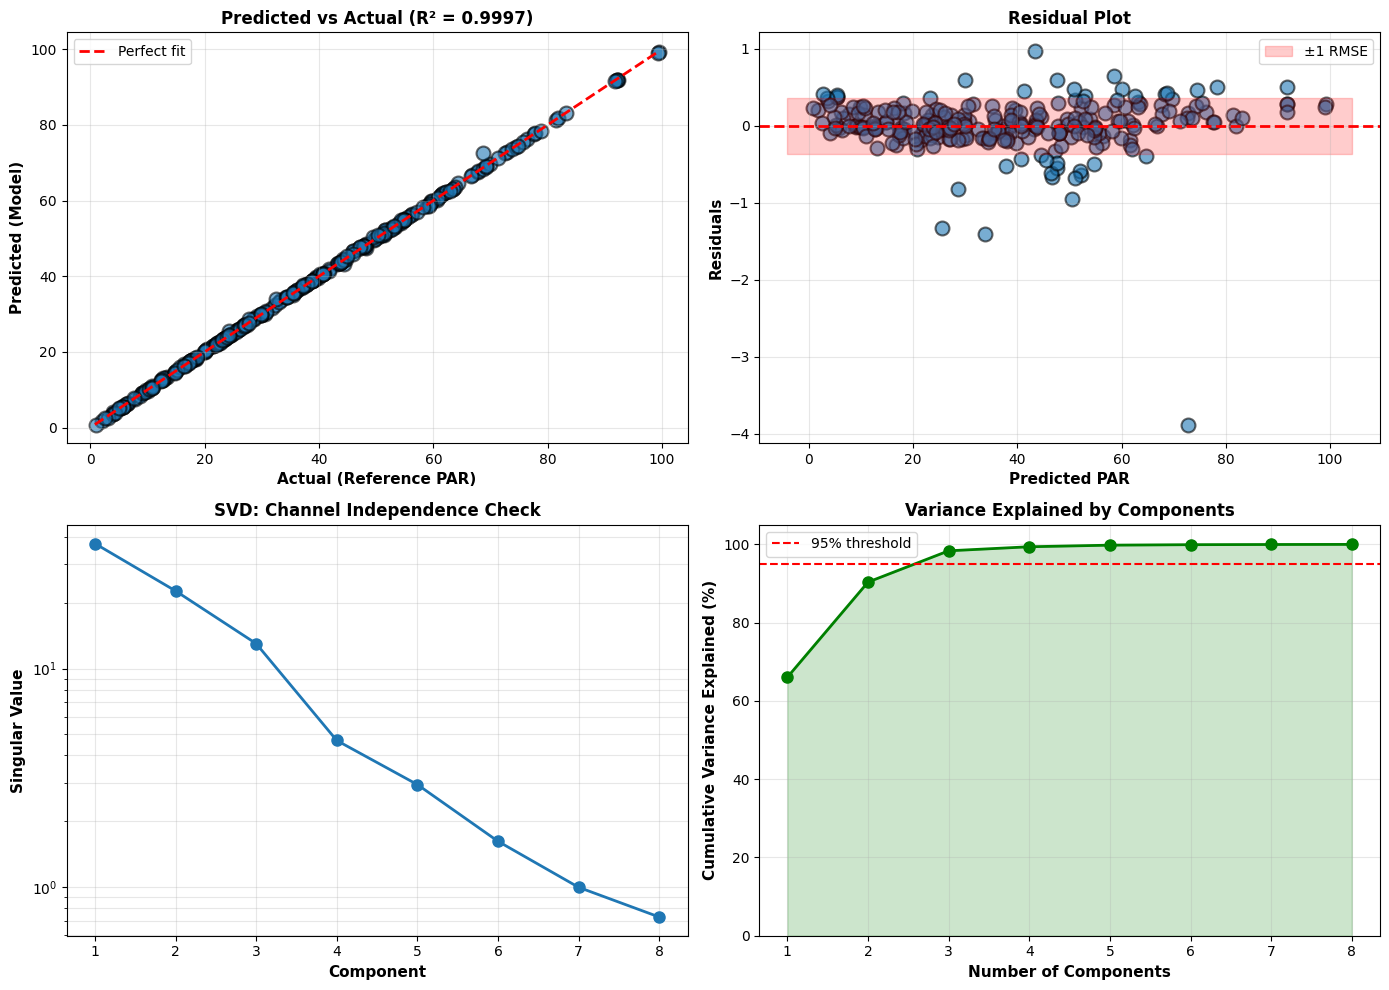

Plots saved to calibration_fit_analysis.png


In [106]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predicted vs Actual using manually collected data
ax = axes[0, 0]
ax.scatter(y_manual, y_pred, s=100, alpha=0.6, edgecolors='k', linewidth=1.5)
lims = [np.min([y_manual.min(), y_pred.min()]), np.max([y_manual.max(), y_pred.max()])]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit')
ax.set_xlabel('Actual (Reference PAR)', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted (Model)', fontsize=11, fontweight='bold')
ax.set_title(f'Predicted vs Actual (R² = {r2:.4f})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Residuals for manually collected data
ax = axes[0, 1]
residuals_data = y_manual - y_pred
ax.scatter(y_pred, residuals_data, s=100, alpha=0.6, edgecolors='k', linewidth=1.5)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.fill_between(ax.get_xlim(), -rmse, rmse, alpha=0.2, color='red', label=f'±1 RMSE')
ax.set_xlabel('Predicted PAR', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Singular Values (log scale)
ax = axes[1, 0]
ax.semilogy(np.arange(1, len(singular_values)+1), singular_values, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Component', fontsize=11, fontweight='bold')
ax.set_ylabel('Singular Value', fontsize=11, fontweight='bold')
ax.set_title('SVD: Channel Independence Check', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

# Plot 4: Cumulative Variance Explained
ax = axes[1, 1]
ax.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance*100, 'o-', linewidth=2, markersize=8, color='green')
ax.axhline(y=95, color='r', linestyle='--', lw=1.5, label='95% threshold')
ax.fill_between(np.arange(1, len(cumulative_variance)+1), 0, cumulative_variance*100, alpha=0.2, color='green')
ax.set_xlabel('Number of Components', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Variance Explained (%)', fontsize=11, fontweight='bold')
ax.set_title('Variance Explained by Components', fontsize=12, fontweight='bold')
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('calibration_fit_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plots saved to calibration_fit_analysis.png")

## Coefficient Inspection & Approval
**Review the coefficients below before uploading.** Adjust if needed.

In [107]:
# Display coefficients for inspection
print("\n" + "=" * 60)
print("CALIBRATION COEFFICIENTS FOR UPLOAD")
print("=" * 60)
coeffs_display = coeffs.copy()
print(f"\nCommand format: cal_par_coeffs,<c1>,<c2>,...,<intercept>")
print(f"\nFull coefficient array (including intercept):")
print(coeffs_display)

# CSV format for upload
coeffs_csv = ",".join([f"{c:.6g}" for c in coeffs_display])
print(f"\nCSV format for upload:")
print(coeffs_csv)

# Save to JSON for later use
coeffs_data = {
    'coeffs': coeffs_display.tolist(),
    'channel_coeffs': channels_coeffs.tolist(),
    'intercept': float(intercept),
    'r2': float(r2),
    'rmse': float(rmse),
    'condition_number': float(cond_number),
    'timestamp': None  # Will be filled if uploaded
}

with open('calibration_coeffs.json', 'w') as f:
    json.dump(coeffs_data, f, indent=2)
print(f"\nCoefficients saved to calibration_coeffs.json")
print("=" * 60)


CALIBRATION COEFFICIENTS FOR UPLOAD

Command format: cal_par_coeffs,<c1>,<c2>,...,<intercept>

Full coefficient array (including intercept):
[ 7.18936226e-03  3.09967221e-03  2.45317143e-03  2.54672379e-03
  2.13550011e-03  1.99841881e-03  2.23817584e-03  4.76634533e-04
 -5.25975882e-01]

CSV format for upload:
0.00718936,0.00309967,0.00245317,0.00254672,0.0021355,0.00199842,0.00223818,0.000476635,-0.525976

Coefficients saved to calibration_coeffs.json


## Upload Coefficients
**Run this cell only after reviewing the coefficients above.**

In [ ]:
# CONFIRM UPLOAD
CONFIRM_UPLOAD = False  # Set to True to enable upload

def upload_coeffs(port, coeffs):
    """Upload coefficients to MiniPAR."""
    vals = ",".join([f"{c:.6g}" for c in coeffs])
    cmd = f"cal_par_coeffs,{vals}\n"
    print(f"Sending: {cmd.strip()}")
    
    with serial.Serial(port, baudrate=BAUD_RATE, timeout=1) as ser:
        ser.reset_input_buffer()
        ser.write(cmd.encode())
        time.sleep(0.2)
        resp = ser.readline().decode(errors='ignore').strip()
    return resp

if CONFIRM_UPLOAD:
    print(f"Uploading coefficients to {PORT_MINIPAR}...")
    try:
        response = upload_coeffs(PORT_MINIPAR, coeffs)
        print(f"Upload response: {response}")
        print("✓ Coefficients uploaded successfully!")
    except Exception as e:
        print(f"✗ Upload failed: {e}")
else:
    print("Upload disabled. Set CONFIRM_UPLOAD = True to proceed.")

## Post-Validation: Verify Calibration
Compare MiniPAR 'par' readings against reference sensor at several current levels.

In [ ]:
# Wait for user to run post-validation
print("\nPost-validation requires running the calibrated device.")
print("Ensure coefficients have been uploaded and device rebooted if needed.\n")

# Test currents (subset of calibration range)
test_currents = [0.3, 0.7, 1.2]
validation_data = []

print("Running validation sweep...\n")
print(f"{'Current (A)':<15} {'Reference (PAR)':<20} {'MiniPAR (PAR)':<20} {'Error (abs)':<15} {'Error (%)':<15}")
print("-" * 85)

for I in test_currents:
    if PORT_DC:
        set_current(PORT_DC, I)
    time.sleep(1.0)
    
    try:
        ref = getPAR_TIA(PORT_REF)
        par = get_par(PORT_MINIPAR)
        error_abs = abs(par - ref)
        error_pct = (error_abs / ref * 100) if ref != 0 else 0
        
        validation_data.append({
            'current': I,
            'ref': ref,
            'par': par,
            'error_abs': error_abs,
            'error_pct': error_pct
        })
        
        print(f"{I:<15.2f} {ref:<20.4f} {par:<20.4f} {error_abs:<15.4f} {error_pct:<15.2f}%")
    except Exception as e:
        print(f"{I:<15.2f} ERROR: {e}")

if validation_data:
    errors_abs = [d['error_abs'] for d in validation_data]
    errors_pct = [d['error_pct'] for d in validation_data]
    print("-" * 85)
    print(f"{'Mean error':<15} {np.mean([d['ref'] for d in validation_data]):<20.4f} {np.mean([d['par'] for d in validation_data]):<20.4f} {np.mean(errors_abs):<15.4f} {np.mean(errors_pct):<15.2f}%")
    print("\nValidation complete.")
else:
    print("No validation data collected.")

## Validation Summary

In [ ]:
if validation_data:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    # Plot 1: Reference vs Calibrated PAR
    ax = axes[0]
    refs = [d['ref'] for d in validation_data]
    pars = [d['par'] for d in validation_data]
    ax.scatter(refs, pars, s=150, alpha=0.7, edgecolors='k', linewidth=2)
    lims = [min(refs + pars), max(refs + pars)]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect agreement')
    ax.set_xlabel('Reference Sensor PAR', fontsize=11, fontweight='bold')
    ax.set_ylabel('MiniPAR (Calibrated) PAR', fontsize=11, fontweight='bold')
    ax.set_title('Post-Validation: MiniPAR vs Reference', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot 2: Validation Errors
    ax = axes[1]
    currents_val = [d['current'] for d in validation_data]
    errors_pct = [d['error_pct'] for d in validation_data]
    colors = ['green' if e < 5 else 'orange' if e < 10 else 'red' for e in errors_pct]
    ax.bar(range(len(currents_val)), errors_pct, color=colors, alpha=0.7, edgecolor='k', linewidth=1.5)
    ax.axhline(y=5, color='green', linestyle='--', lw=1.5, label='5% threshold')
    ax.axhline(y=10, color='orange', linestyle='--', lw=1.5, label='10% threshold')
    ax.set_xticks(range(len(currents_val)))
    ax.set_xticklabels([f"{c:.1f}A" for c in currents_val])
    ax.set_ylabel('Absolute Error (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Current', fontsize=11, fontweight='bold')
    ax.set_title('Validation Errors by Current Level', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('validation_results.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("Validation plot saved to validation_results.png")
else:
    print("No validation data to plot.")